In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import re


# ────────────────────────────────────────────────────────────────────────────
# LAYOUT EVENT AGGREGATION: Show start-end periods for consecutive layout events
# ────────────────────────────────────────────────────────────────────────────
def extract_node_id(details_str):
    """Extract nodeId from details JSON string"""
    if pd.isna(details_str):
        return None
    # Extract nodeId using regex
    match = re.search(r"'nodeId'\s*:\s*'([^']+)'", str(details_str))
    if not match:
        match = re.search(r'"nodeId"\s*:\s*"([^"]+)"', str(details_str))
    return match.group(1) if match else None


def aggregate_layout_events(df, time_gap_threshold=5.0):
    """Aggregate truly consecutive layout events by nodeId to show start-end periods

    Args:
        df: DataFrame with events
        time_gap_threshold: Maximum seconds between events to consider them consecutive
    """
    layout_event_names = [
        "layout.node.moved",
        "layoutboard.node.resizable.resized",
        "`layoutboard.node.resizable`",
    ]

    aggregated = []

    # Process each id_group separately
    for id_group in df["id_group"].unique():
        group_df = df[df["id_group"] == id_group].copy()
        group_df = group_df.sort_values("timestamp").reset_index(drop=True)

        # Find consecutive sequences of layout events for each nodeId
        i = 0
        while i < len(group_df):
            row = group_df.iloc[i]

            # Skip non-layout events
            if row["event"] not in layout_event_names:
                i += 1
                continue

            # Extract nodeId for this layout event
            node_id = extract_node_id(row["details"])
            if pd.isna(node_id):
                i += 1
                continue

            # Start a consecutive sequence
            sequence_start = i
            sequence_events = [row]

            # Look ahead to find consecutive layout events for same nodeId
            j = i + 1
            while j < len(group_df):
                next_row = group_df.iloc[j]

                # If it's not a layout event for the same node, break
                if (
                    next_row["event"] not in layout_event_names
                    or extract_node_id(next_row["details"]) != node_id
                ):
                    break

                # # Check time gap
                # time_diff = (next_row["timestamp"] - sequence_events[-1]["timestamp"]).total_seconds()
                # if time_diff > time_gap_threshold:
                #     break

                sequence_events.append(next_row)
                j += 1

            # Process the found sequence
            if len(sequence_events) == 1:
                # Single event, keep as is
                event_row = sequence_events[0]
                aggregated.append(
                    {
                        "id_group": id_group,
                        "nodeId": node_id,
                        "event": f"layout.{event_row['event'].split('.')[1]}.{event_row['event'].split('.')[2]}",
                        "timestamp": event_row["timestamp"],
                        "seq_idx": None,
                        "is_start": True,
                        "is_end": True,
                        "duration": 0,
                        "event_count": 1,
                    }
                )
            else:
                # Multiple consecutive events, create start-end pair
                first = sequence_events[0]
                last = sequence_events[-1]
                duration = (last["timestamp"] - first["timestamp"]).total_seconds()

                # Start marker
                aggregated.append(
                    {
                        "id_group": id_group,
                        "nodeId": node_id,
                        "event": "layout.start",
                        "timestamp": first["timestamp"],
                        "seq_idx": None,
                        "is_start": True,
                        "is_end": False,
                        "duration": duration,
                        "event_count": len(sequence_events),
                    }
                )

                # # End marker
                # aggregated.append(
                #     {
                #         "id_group": id_group,
                #         "nodeId": node_id,
                #         "event": "layout.end",
                #         "timestamp": last["timestamp"],
                #         "seq_idx": None,
                #         "is_start": False,
                #         "is_end": True,
                #         "duration": duration,
                #         "event_count": len(sequence_events),
                #     }
                # )

            # Move to next event after this sequence
            i = sequence_start + len(sequence_events)

    return pd.DataFrame(aggregated)

In [394]:
import pandas as pd
import ast, json
import numpy as np


def parse_details(details_str):
    if details_str is None or (isinstance(details_str, float) and pd.isna(details_str)):
        return {}
    if isinstance(details_str, dict):
        return details_str
    if isinstance(details_str, str):
        try:
            return json.loads(details_str)
        except Exception:
            pass
        try:
            return ast.literal_eval(details_str)
        except Exception:
            return {}
    return {}


# ====== 설정 ======
INPUT_CSV = "csv_log/OOPT_filtered_all.csv"  # 원본 CSV 경로
OUTPUT_CSV = "csv_log/OOPT_filtered_all.csv"  # 수정본 저장 경로

# 매핑 사전
label_map = {
    "class_instances_reset": "class.instances_reset",
    "instance_created_from_detection": "instance.created_from_detection",
    "layout_board.new_box_positioned": "instance.created_from_text",
}

# ====== 실행 ======
df = pd.read_csv(INPUT_CSV)

# 'event'라는 컬럼이 있다고 가정
df["event"] = df["event"].replace(label_map)

# 2) ★ instance.updated 세분화: text / graph (둘 다면 우선순위는 text로 처리)
if "details" in df.columns:
    det = df["details"].apply(parse_details)
    text_changed = det.apply(lambda d: bool(d.get("text_changed", False)))
    graph_changed = det.apply(lambda d: bool(d.get("graph_changed", False)))
    is_updated = df["event"].eq("instance.updated")

    # (둘 다 True인 경우 → text 우선; 필요시 'both'로 바꾸세요)
    df.loc[is_updated & text_changed, "event"] = "instance.updated.text"
    df.loc[is_updated & ~text_changed & graph_changed, "event"] = (
        "instance.updated.graph"
    )
    # (둘 다 False면 그대로 'instance.updated' 유지)

df.to_csv(OUTPUT_CSV, index=False)

# df_all = df.copy()
# df = df_all.copy()

if "timestamp" in df.columns:
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["id_group", "timestamp"]).copy()
else:
    df = df.sort_values(["id_group"]).copy()

# Separate layout and non-layout events
non_layout_events = df[
    ~df["event"].isin(["layout.node.moved", "layoutboard.node.resizable.resized"])
].copy()
layout_aggregated = aggregate_layout_events(df)

# Combine and assign sequence indices
all_events = []

for id_group in sorted(df["id_group"].unique()):
    # Get non-layout events for this group
    group_non_layout = non_layout_events[
        non_layout_events["id_group"] == id_group
    ].copy()
    group_layout = layout_aggregated[layout_aggregated["id_group"] == id_group].copy()

    # Combine and sort by timestamp
    group_events = []

    for _, row in group_non_layout.iterrows():
        group_events.append(
            {
                "id_group": id_group,
                "event": row["event"],
                "timestamp": row["timestamp"],
                "is_layout": False,
                "is_start": False,
                "is_end": False,
                "duration": 0,
                "event_count": 1,
            }
        )

    for _, row in group_layout.iterrows():
        group_events.append(
            {
                "id_group": id_group,
                "event": row["event"],
                "timestamp": row["timestamp"],
                "is_layout": True,
                "is_start": row["is_start"],
                "is_end": row["is_end"],
                "duration": row["duration"],
                "event_count": row["event_count"],
            }
        )

    # Sort by timestamp and assign sequence indices
    group_events.sort(key=lambda x: x["timestamp"])
    for i, event in enumerate(group_events):
        event["seq_idx"] = i
        all_events.append(event)

# Create final dataframe
df_final = pd.DataFrame(all_events)
df_final = df_final[
    (df_final["event"] != "layout.node.moved")
    & (df_final["event"] != "layout.node.resizable")
]

df.to_csv(OUTPUT_CSV, index=False)

print(f"Total events after aggregation: {len(df_final)}")
print(
    f"Layout start/end pairs: {len(df_final[df_final['event'].str.startswith('layout.')])}"
)

Total events after aggregation: 504
Layout start/end pairs: 101


In [437]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALIZATION SETUP WITH IMPROVED COLORS AND GROUPING
# ────────────────────────────────────────────────────────────────────────────

# Updated color scheme with layout events
base_colors = {
    "class": plt.cm.Blues,  # Class events - Blue
    "instance": plt.cm.Reds,  # Instance events - Red
    "object": plt.cm.Greens,  # Object events - Green
    "edge": plt.cm.Purples,  # Other events - Purple
    "layout": plt.cm.Greys,  # Layout events - Orange (NEW)
    "api": plt.cm.Wistia,  # API events - Grey
}

# Categorize events with improved grouping
event_types = sorted(df_final["event"].unique())
event_to_group = {}
for ev in event_types:
    if ev == "api.generate_image.succeeded":
        event_to_group[ev] = "api"
    elif ev.startswith("layout."):
        event_to_group[ev] = "layout"
    elif ev.startswith("class"):
        event_to_group[ev] = "class"
    elif ev.startswith("instance"):
        event_to_group[ev] = "instance"
    elif ev.startswith("object_node"):
        event_to_group[ev] = "object"
    else:
        event_to_group[ev] = "edge"

# Assign colors
event_to_color = {}
for group in set(event_to_group.values()):
    group_events = [ev for ev, g in event_to_group.items() if g == group]
    cmap = base_colors[group]
    n = len(group_events)
    colors = [cmap(x) for x in np.linspace(0.9, 0.3, max(n, 1))]
    for i, ev in enumerate(group_events):
        event_to_color[ev] = colors[i] if n > 1 else cmap(0.7)

# Enhanced marker mapping with same color but different shapes for instance creation
# marker_map = {
#     # Class events
#     "class.created": "o",
#     "class.updated": "o",
#     "class.instances_reset": "o",
#     # Instance events - SAME COLOR, DIFFERENT SHAPES
#     "instance.created_from_class": "o",  # Diamond
#     "instance.created_from_text": "s",  # Circle
#     "instance.created_from_detection": "^",  # Triangle
#     "instance.updated.text": "s",  # Square
#     "instance.updated.graph": "s",  # Square
#     # Layout events - distinct markers
#     "layout.start": "s",  # Start marker
#     "layout.end": "s",  # End marker
#     "layout.moved": "s",  # Individual move
#     "layout.resized": "v",  # Individual resize
#     # Object events
#     "object_node.extract.confirmed": "s",  # Hexagon
#     # API events
#     "api.generate_image.succeeded": "*",  # Star
# "relationship_node.created": "s",
#     "relationship_node.edited": "s",
# }
marker_map = {
    # Class events
    "class.created": "o",
    "class.updated": "_",
    "class.instances_reset": "_",
    # Instance events - SAME COLOR, DIFFERENT SHAPES
    "instance.created_from_class": "o",  # Diamond
    "instance.created_from_text": "s",  # Circle
    "instance.created_from_detection": "^",  # Triangle
    "instance.updated.text": "_",  # Square
    "instance.updated.graph": "_",  # Square
    # Layout events - distinct markers
    "layout.start": "_",  # Start marker
    "layout.end": "_",  # End marker
    "layout.moved": "s",  # Individual move
    "layout.resized": "v",  # Individual resize
    # Object events
    "object_node.extract.confirmed": "s",  # Hexagon
    # API events
    "api.generate_image.succeeded": "*",  # Star
    "relationship_node.created": "s",
    "relationship_node.edited": "_",
}

alpha_map = {
    "instance.created_from_class": 0.95,
    "instance.created_from_text": 0.95,
    "instance.created_from_detection": 0.95,
    "instance.updated.text": 0.65,
    "instance.updated.graph": 0.65,
    "layout.start": 0.7,
    "layout.end": 0.7,
    "api.generate_image.succeeded": 1,
}

# Make instance creation events same color
instance_creation_color = base_colors["instance"](0.7)
for event in [
    "instance.created_from_class",
    "instance.created_from_text",
    "instance.created_from_detection",
]:
    if event in event_to_color:
        event_to_color[event] = instance_creation_color

# Make instance creation events same color
layout_color = base_colors["layout"](0.7)
for event in ["layout.start", "layout.end", "layout.moved", "layout.resized"]:
    if event in event_to_color:
        event_to_color[event] = layout_color

api_color = base_colors["api"](0.3)
event_to_color["api.generate_image.succeeded"] = api_color

# 표시용 그룹 이름
group_display = {
    "class": "Class-related",
    "instance": "Instance",
    "object": "Object",
    "layout": "Layout",
    "edge": "Edge",
    "api": "API",
    "other": "Etc.",
}

# 표시용 이벤트 이름
event_display = {
    "class.created": "Create Class",
    "class.updated": "Update Class",
    "class.instances_reset": "Reset Class Instances",
    "instance.created_from_class": "Create Instance from Class",
    "instance.created_from_text": "Create Instance from Text",
    "instance.created_from_detection": "Create Instance from Detection",
    "instance.updated.text": "Update Instance",
    "instance.updated.graph": "Update Instance",
    "layout.start": "Update Layout",
    "layout.end": "Layout End",
    "layout.moved": "Move",
    "layout.resized": "Resize",
    "object_node.extract.confirmed": "Object Extract",
    "api.generate_image.succeeded": "Image Generated",
    "relationship_node.created": "Create Edge",
    "relationship_node.edited": "Update Edge",
}

from matplotlib.lines import Line2D


def make_group_event_legend(
    ax,
    event_types,
    event_to_group,
    event_to_color,
    marker_map,
    group_display,
    event_display,
    title="Event Groups + Events",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    group_order=None,  # ✅ 그룹 순서 지정
    event_order=None,  # ✅ (옵션) 그룹 내 이벤트 순서 지정
    events_to_show=None,
):
    """'그룹이름 – 이벤트이름' 조합으로 커스텀 범례 생성 (그룹/이벤트 순서 지정 가능)"""
    # 1) 그룹 순서 랭크 만들기
    if group_order is None:
        # 지정 없으면 group_display 키 순서 사용
        group_order = list(group_display.keys())
    group_rank = {g: i for i, g in enumerate(group_order)}

    # 2) (옵션) 이벤트 순서 랭크 만들기
    # event_order 예시:
    # {"class": ["class.created", "class.updated"], "instance": ["instance.created_from_class", ...]}
    event_rank = {}
    if event_order:
        for g, ev_list in event_order.items():
            event_rank.update({ev: i for i, ev in enumerate(ev_list)})

    # 3) 정렬용 키 함수
    def sort_key(ev):
        g = event_to_group.get(ev, "other")
        gk = group_rank.get(g, 10**6)
        # 이벤트 순서가 주어지면 우선, 아니면 표시용 이름으로 알파벳 정렬
        ek = event_rank.get(ev, 10**6)
        ename = event_display.get(ev, ev)
        return (gk, ek, ename)

    # 4) 정렬된 이벤트 순회
    handles, labels, seen = [], [], set()
    for ev in sorted(event_types, key=sort_key):
        if events_to_show and ev not in events_to_show:
            continue
        grp_key = event_to_group.get(ev, "other")
        grp_name = group_display.get(grp_key, grp_key)
        ev_name = event_display.get(ev, ev)
        label = f"{grp_name} – {ev_name}"
        if label in seen:
            continue
        seen.add(label)

        color = event_to_color.get(ev, "black")
        marker = marker_map.get(ev, "s")
        handles.append(
            Line2D(
                [0],
                [0],
                marker=marker,
                linestyle="",
                markerfacecolor=color,
                markeredgecolor=color,
                markersize=10,
                alpha=1.0,
            )
        )
        labels.append(label)

    leg = ax.legend(
        handles, labels, title=title, loc=loc, bbox_to_anchor=bbox_to_anchor
    )
    return leg

In [396]:
import pandas as pd
import matplotlib.pyplot as plt

# df_all = pd.read_csv("csv_log/OOPT_filtered_all.csv")

df_all = df_final.copy()

# 각 id_group별로 첫 이벤트를 0초로 맞추기
if "timestamp" in df_all.columns:
    if not pd.api.types.is_datetime64_any_dtype(df_all["timestamp"]):
        df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
    df_all["time_norm"] = df_all.groupby("id_group")["timestamp"].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    x = df_all["time_norm"]
else:
    x = df_all.index

# id_group별로 y축 배치
id_groups_sorted = sorted(df_all["id_group"].unique())
id_group_to_y = {id_: i for i, id_ in enumerate(id_groups_sorted)}
y = df_all["id_group"].map(id_group_to_y)

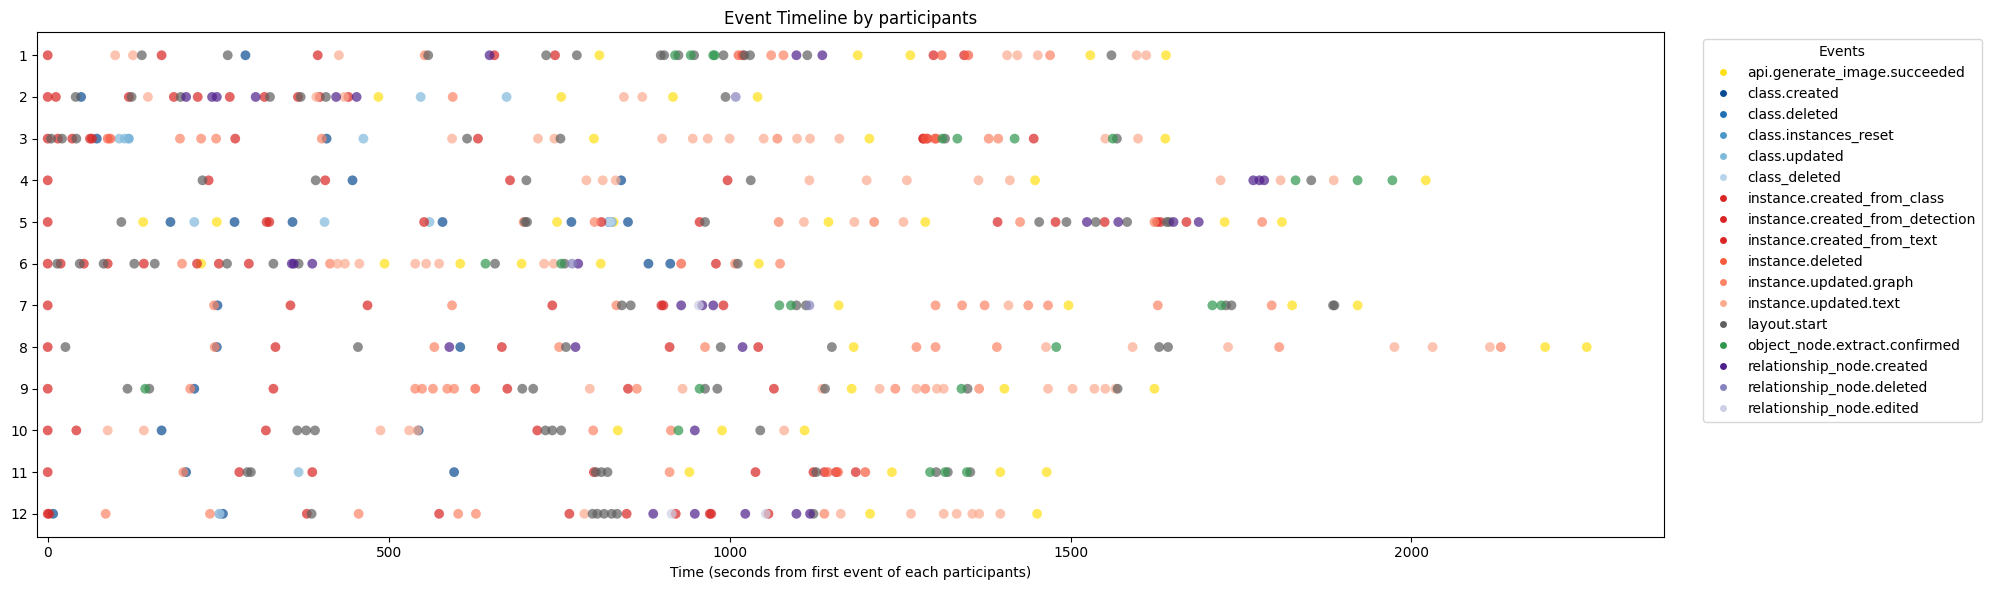

In [397]:
from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(20, max(6, len(id_groups_sorted) * 0.4)))
rng = np.random.default_rng(42)

legend_elems = []  # legend 수동 구성

for ev in event_types:
    mask = df_all["event"] == ev
    group = [g for e, g in zip(event_types, event_to_group) if e == ev][0]
    y_jitter = y[
        mask
    ]  # .to_numpy(dtype=float) + rng.uniform(-0.05, 0.05, size=mask.sum())

    # 기본 스타일
    scatter_args = dict(
        x=x[mask],
        y=y_jitter,
        color=event_to_color[ev],
        marker="o",
        s=50,
        alpha=0.7,
        edgecolors="none",
        linewidths=0,
    )

    # # 강조 이벤트
    # if ev in ['class.created', 'class.updated',
    #           'instance.created_from_class', 'instance.updated']:
    #     scatter_args.update(dict(
    #         s=50,
    #         edgecolors='k',
    #         linewidths=0.8,
    #         # # # # zorder=5
    #     ))

    plt.scatter(**scatter_args)

    # legend entry 생성
    legend_elems.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=event_to_color[ev],
            #    markeredgecolor=('k' if ev in ['class.created','class.updated',
            #                                   'instance.created_from_class','instance.updated'] else 'none'),
            markersize=(
                6
                if ev
                in [
                    "class.created",
                    "class.updated",
                    "instance.created_from_class",
                    "instance.updated",
                ]
                else 6
            ),
            label=ev,
        )
    )

plt.xlabel("Time (seconds from first event of each participants)")
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title("Event Timeline by participants")

plt.legend(
    handles=legend_elems, bbox_to_anchor=(1.02, 1), loc="upper left", title="Events"
)
plt.xlim(left=-15)
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

In [398]:
import re
import json
import pandas as pd
from typing import Optional, Tuple

INPUT_CSV = "csv_log/OOPT_filtered_all.csv"
OUTPUT_CSV = "csv_log/OOPT_filtered_all_deleted.csv"
REPORT_CSV = "csv_log/OOPT_deleted_before_report.csv"


# ── 타임스탬프 컬럼 선택 ───────────────────────────────────────────────
def pick_ts_col(df: pd.DataFrame) -> str:
    for c in ("timestamp", "ts", "time", "created_at", "log_ts"):
        if c in df.columns:
            return c
    raise ValueError(
        "타임스탬프 컬럼이 필요합니다 (timestamp/ts/time/created_at/log_ts 중 하나)."
    )


# ── details 문자열에서 key:"value" or key:'value' 추출 ───────────────
def rx_get(details: str, key: str) -> Optional[str]:
    if not isinstance(details, str):
        details = "" if pd.isna(details) else str(details)
    # "key": "value"
    m = re.search(rf'"{re.escape(key)}"\s*:\s*"([^"]+)"', details)
    if m:
        return m.group(1)
    # 'key': 'value'
    m = re.search(rf"'{re.escape(key)}'\s*:\s*'([^']+)'", details)
    if m:
        return m.group(1)
    # "key": 123  (숫자/토큰)
    m = re.search(rf'"{re.escape(key)}"\s*:\s*([^\s,}}]+)', details)
    if m:
        return m.group(1).strip('"').strip("'")
    # 'key': 123
    m = re.search(rf"'{re.escape(key)}'\s*:\s*([^\s,}}]+)", details)
    if m:
        return m.group(1).strip('"').strip("'")
    return None


# ── 삭제/제거 이벤트 식별 ─────────────────────────────────────────────
def is_delete_event(ev: str) -> bool:
    ev = ev or ""
    return ("deleted" in ev) or ("removed" in ev)


# ── instance/class ID 추출: id 컬럼 우선, 없으면 details에서 ──────────
def extract_instance_id(row: pd.Series) -> Optional[str]:
    if "id" in row and pd.notna(row["id"]):
        return str(row["id"])
    det = row.get("details", "")
    for k in ("instanceId", "sharedId", "nodeId", "id"):
        v = rx_get(det, k)
        if v:
            return v
    return None


def extract_class_id(row: pd.Series) -> Optional[str]:
    if "id" in row and pd.notna(row["id"]):
        return str(row["id"])
    det = row.get("details", "")
    for k in ("classId", "id"):
        v = rx_get(det, k)
        if v:
            return v
    return None


# ── relationship (src,dst) 정규화 ─────────────────────────────────────
def extract_rel_pair(row: pd.Series) -> Optional[Tuple[str, str]]:
    det = row.get("details", "")
    rid = (
        rx_get(det, "relationship_id")
        or rx_get(det, "relationshipId")
        or rx_get(det, "relId")
        or rx_get(det, "edgeId")
        or rx_get(det, "id")
    )
    # 1) relationship_id에서 직접 파싱
    if rid:
        if "->" in rid:  # created 형식: src->dst:rel
            try:
                src, rest = rid.split("->", 1)
                dst = rest.split(":", 1)[0]
                return (src, dst)
            except Exception:
                pass
        if "-" in rid:  # deleted/edited 형식: src-dst
            parts = rid.split("-", 1)
            if len(parts) == 2:
                return (parts[0], parts[1])
    # 2) endpoint로 대체
    src = rx_get(det, "sourceId") or rx_get(det, "source") or rx_get(det, "from")
    dst = rx_get(det, "targetId") or rx_get(det, "target") or rx_get(det, "to")
    if src and dst:
        return (src, dst)
    return None


# ── 로드 & 정렬 ───────────────────────────────────────────────────────
df = pd.read_csv(INPUT_CSV)
ts = pick_ts_col(df)
df[ts] = pd.to_datetime(df[ts], errors="coerce")
df = df.sort_values(ts, kind="mergesort").reset_index(drop=True)

# ── 1) 삭제시각 맵: 가장 이른 삭제시각 기록 + 삭제행 인덱스 수집 ───────
inst_del_ts, class_del_ts, rel_del_ts = {}, {}, {}
delete_row_idx = set()

for i, r in df.iterrows():
    ev, t = str(r.get("event", "")), r[ts]
    if pd.isna(t):
        continue

    if is_delete_event(ev) and "instance" in ev:
        iid = extract_instance_id(r)
        if iid:
            inst_del_ts[iid] = min(t, inst_del_ts.get(iid, t))
            delete_row_idx.add(i)

    if is_delete_event(ev) and "class" in ev:
        cid = extract_class_id(r)
        if cid:
            class_del_ts[cid] = min(t, class_del_ts.get(cid, t))
            delete_row_idx.add(i)

    if is_delete_event(ev) and "relationship" in ev:
        pair = extract_rel_pair(r)
        if pair:
            rel_del_ts[pair] = min(t, rel_del_ts.get(pair, t))
            delete_row_idx.add(i)

# ── 2) 제거 마스크: 삭제행 + 삭제 이전행 ───────────────────────────────
drop = pd.Series(False, index=df.index)
report = []

for i, r in df.iterrows():
    ev, t = str(r.get("event", "")), r[ts]
    if pd.isna(t):
        continue

    # A) 삭제 이벤트 자체는 무조건 제거
    if i in delete_row_idx:
        drop.iat[i] = True
        report.append(("delete_row", "", str(t), ev))
        continue

    # B) 삭제 이전의 관련 이벤트 제거 (이전만: t < del_ts)
    if "instance" in ev:
        iid = extract_instance_id(r)
        if iid and iid in inst_del_ts and t < inst_del_ts[iid]:
            drop.iat[i] = True
            report.append(("instance", iid, str(t), ev))
            continue

    if "class" in ev:
        cid = extract_class_id(r)
        if cid and cid in class_del_ts and t < class_del_ts[cid]:
            drop.iat[i] = True
            report.append(("class", cid, str(t), ev))
            continue

    if "relationship" in ev:
        pair = extract_rel_pair(r)
        if pair and pair in rel_del_ts and t < rel_del_ts[pair]:
            drop.iat[i] = True
            report.append(("relationship", f"{pair[0]}-{pair[1]}", str(t), ev))
            continue

# ── 3) 저장 ───────────────────────────────────────────────────────────
df_clean = df.loc[~drop].copy()
df_clean.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(
    f"✅ 완료: {INPUT_CSV} → {OUTPUT_CSV} (제거 {drop.sum()}행: 삭제행 + 삭제 이전행)"
)

if report:
    pd.DataFrame(report, columns=["type", "key", "event_time", "event"]).to_csv(
        REPORT_CSV, index=False, encoding="utf-8-sig"
    )
    print(f"📝 제거 요약: {REPORT_CSV}")

✅ 완료: csv_log/OOPT_filtered_all.csv → csv_log/OOPT_filtered_all_deleted.csv (제거 47행: 삭제행 + 삭제 이전행)
📝 제거 요약: csv_log/OOPT_deleted_before_report.csv


In [399]:
df = df_clean.copy()
if "timestamp" in df.columns:
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["id_group", "timestamp"]).copy()
else:
    df = df.sort_values(["id_group"]).copy()

# Separate layout and non-layout events
non_layout_events = df[
    ~df["event"].isin(["layout.node.moved", "layout.node.resizable"])
].copy()
layout_aggregated = aggregate_layout_events(df)

# Combine and assign sequence indices
all_events = []

for id_group in sorted(df["id_group"].unique()):
    # Get non-layout events for this group
    group_non_layout = non_layout_events[
        non_layout_events["id_group"] == id_group
    ].copy()
    group_layout = layout_aggregated[layout_aggregated["id_group"] == id_group].copy()

    # Combine and sort by timestamp
    group_events = []

    for _, row in group_non_layout.iterrows():
        if row["event"] == "layoutboard.node.resizable.resized":
            continue
        group_events.append(
            {
                "id_group": id_group,
                "event": row["event"],
                "timestamp": row["timestamp"],
                "is_layout": False,
                "is_start": False,
                "is_end": False,
                "duration": 0,
                "event_count": 1,
            }
        )

    for _, row in group_layout.iterrows():
        if (
            row["event"] == "layout.node.moved"
            or row["event"] == "layout.node.resizable"
            or row["event"] == "layoutboard.node.resizable.resized"
        ):
            continue

        group_events.append(
            {
                "id_group": id_group,
                "event": row["event"],
                "timestamp": row["timestamp"],
                "is_layout": True,
                "is_start": row["is_start"],
                "is_end": row["is_end"],
                "duration": row["duration"],
                "event_count": row["event_count"],
            }
        )

    # Sort by timestamp and assign sequence indices
    group_events.sort(key=lambda x: x["timestamp"])
    for i, event in enumerate(group_events):
        event["seq_idx"] = i
        all_events.append(event)

# Create final dataframe
df_all = pd.DataFrame(all_events)

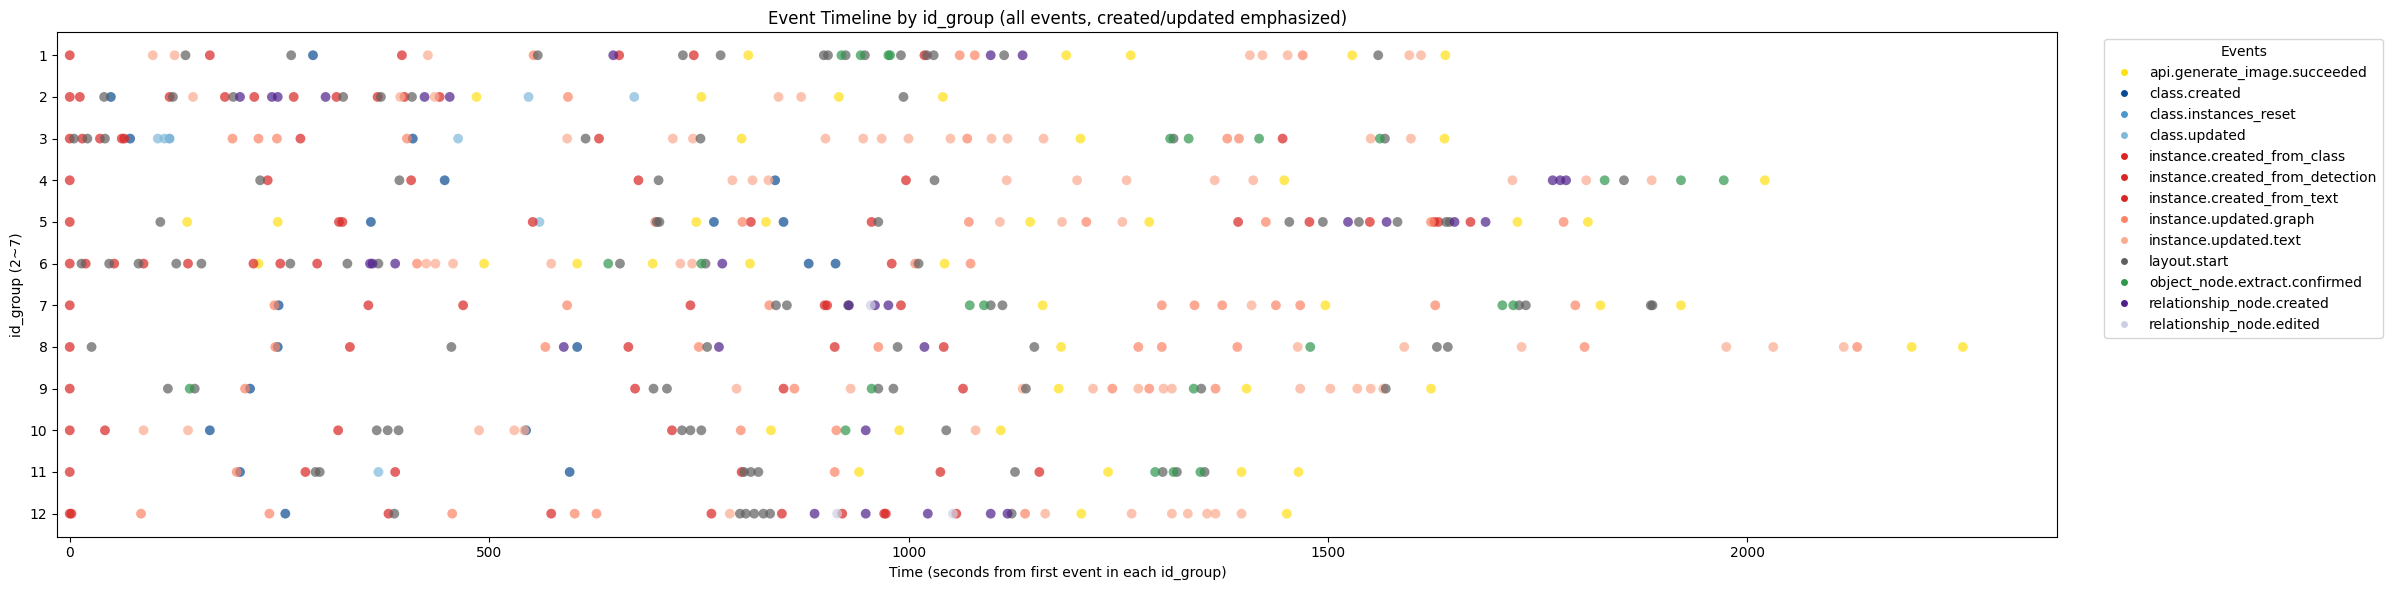

In [400]:
# df_all = pd.read_csv("csv_log/OOPT_filtered_all_deleted.csv")
event_types = sorted(df_all["event"].unique())

# 각 id_group별로 첫 이벤트를 0초로 맞추기
if "timestamp" in df_all.columns:
    if not pd.api.types.is_datetime64_any_dtype(df_all["timestamp"]):
        df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
    df_all["time_norm"] = df_all.groupby("id_group")["timestamp"].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    x = df_all["time_norm"]
else:
    x = df_all.index

# id_group별로 y축 배치
id_groups_sorted = sorted(df_all["id_group"].unique())
id_group_to_y = {id_: i for i, id_ in enumerate(id_groups_sorted)}
y = df_all["id_group"].map(id_group_to_y)

from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(24, max(6, len(id_groups_sorted) * 0.4)))
rng = np.random.default_rng(42)

legend_elems = []  # legend 수동 구성

for ev in event_types:
    mask = df_all["event"] == ev

    group = [g for e, g in zip(event_types, event_to_group) if e == ev][0]
    y_jitter = y[
        mask
    ]  # .to_numpy(dtype=float) + rng.uniform(-0.05, 0.05, size=mask.sum())

    # 기본 스타일
    scatter_args = dict(
        x=x[mask],
        y=y_jitter,
        color=event_to_color[ev],
        marker="o",
        s=50,
        alpha=0.7,
        edgecolors="none",
        linewidths=0,
    )

    plt.scatter(**scatter_args)

    # legend entry 생성
    legend_elems.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=event_to_color[ev],
            #    markeredgecolor=('k' if ev in ['class.created','class.updated',
            #                                   'instance.created_from_class','instance.updated'] else 'none'),
            markersize=(
                6
                if ev
                in [
                    "class.created",
                    "class.updated",
                    "instance.created_from_class",
                    "instance.updated",
                ]
                else 6
            ),
            label=ev,
        )
    )

plt.xlabel("Time (seconds from first event in each id_group)")
plt.ylabel("id_group (2~7)")
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title("Event Timeline by id_group (all events, created/updated emphasized)")
plt.gca().invert_yaxis()
plt.legend(
    handles=legend_elems, bbox_to_anchor=(1.02, 1), loc="upper left", title="Events"
)
plt.xlim(left=-15)

plt.tight_layout()
plt.show()

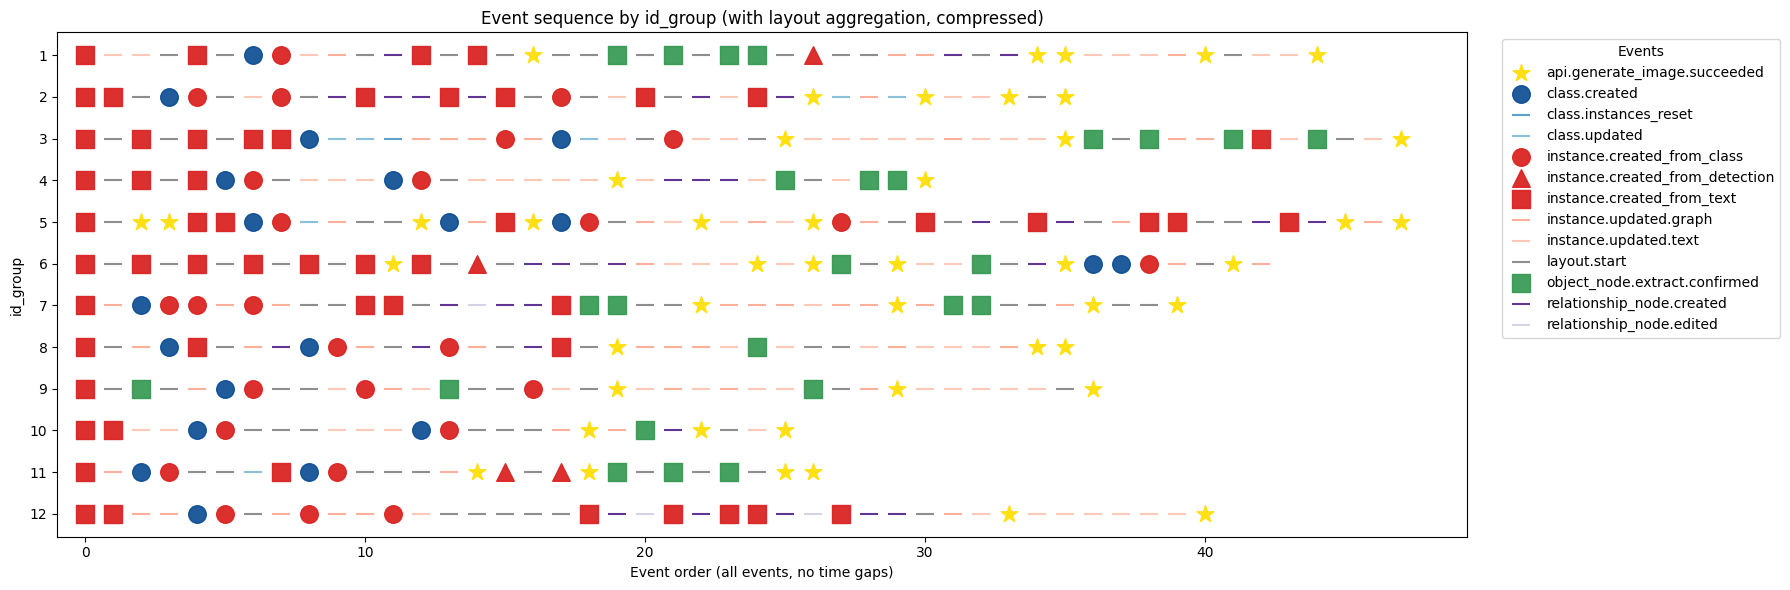

In [434]:
df_all = df_all.drop_duplicates()

# Add time_norm if it doesn't exist
if "time_norm" not in df_all.columns:
    if "timestamp" in df_all.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_all["timestamp"]):
            df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
        df_all["time_norm"] = df_all.groupby("id_group")["timestamp"].transform(
            lambda x: (x - x.min()).dt.total_seconds()
        )
    else:
        df_all["time_norm"] = df_all["seq_idx"]  # Use seq_idx as fallback

df_sorted = df_all.sort_values(["id_group", "time_norm"]).copy()

# 2) 참가자별 순서 인덱스 부여 (반복 이벤트 포함) - use existing seq_idx or create new
if "seq_idx" not in df_sorted.columns:
    df_sorted["seq_idx"] = df_sorted.groupby("id_group").cumcount()

# 3) 플롯
event_types = sorted(df_sorted["event"].unique())

# id_group별로 y축 배치
id_groups_sorted = sorted(df_all["id_group"].unique())
id_group_to_y = {id_: i for i, id_ in enumerate(id_groups_sorted)}

plt.figure(figsize=(18, max(6, len(id_groups_sorted) * 0.4)))

for ev in event_types:
    mask = df_sorted["event"] == ev
    marker = marker_map.get(ev, "_")  # 기본은 네모
    alpha = alpha_map.get(ev, 0.9)
    # edge   = edge_map.get(ev, 'none')
    plt.scatter(
        df_sorted.loc[mask, "seq_idx"],  # X = 이벤트 순서 (0,1,2,…)
        df_sorted.loc[mask, "id_group"].map(id_group_to_y),  # Y = 참가자
        color=event_to_color[ev],
        marker=marker,
        s=160,
        alpha=alpha,
        # edgecolors=edge, linewidths=0.8 if edge!='none' else 0,
        label=ev if ev not in plt.gca().get_legend_handles_labels()[1] else None,
    )

plt.xlabel("Event order (all events, no time gaps)")
plt.ylabel("id_group")
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title("Event sequence by id_group (with layout aggregation, compressed)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Events")
plt.xlim(left=-1)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [403]:
# Sort by id_group, seq_idx
df_sorted = df_sorted.sort_values(["id_group", "seq_idx"]).copy()
df_sorted.head(20)

,id_group,event,timestamp,is_layout,is_start,is_end,duration,event_count,seq_idx,time_norm,cat4
0,1,instance.created_from_text,2000-01-01 11:43:05,False,False,False,0.0,1,0,0.0,None
1,1,instance.updated.text,2000-01-01 11:44:44,False,False,False,0.0,1,1,99.0,None
2,1,instance.updated.text,2000-01-01 11:45:10,False,False,False,0.0,1,2,125.0,None
3,1,layout.start,2000-01-01 11:45:23,True,True,False,25.0,9,3,138.0,None
4,1,instance.created_from_text,2000-01-01 11:45:52,False,False,False,0.0,1,4,167.0,None
5,1,layout.start,2000-01-01 11:47:29,True,True,False,9.0,4,5,264.0,None
6,1,class.created,2000-01-01 11:47:55,False,False,False,0.0,1,6,290.0,None
7,1,instance.created_from_class,2000-01-01 11:49:41,False,False,False,0.0,1,7,396.0,None
8,1,instance.updated.text,2000-01-01 11:50:12,False,False,False,0.0,1,8,427.0,None
9,1,instance.updated.graph,2000-01-01 11:52:18,False,False,False,0.0,1,9,553.0,None


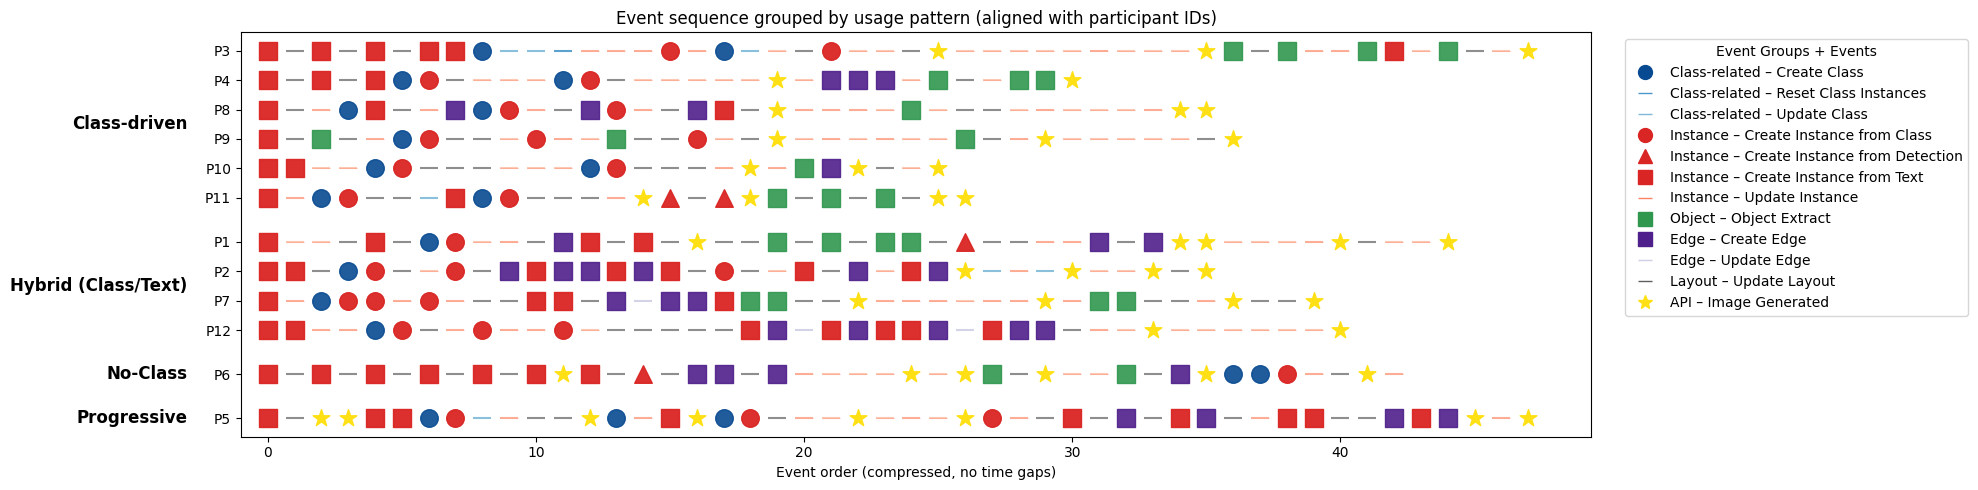

In [442]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ---- 1) 그룹 매핑 ----
group_map = {
    3: "Class-driven",
    4: "Class-driven",
    8: "Class-driven",
    9: "Class-driven",
    10: "Class-driven",
    11: "Class-driven",
    1: "Hybrid (Class/Text)",
    2: "Hybrid (Class/Text)",
    7: "Hybrid (Class/Text)",
    12: "Hybrid (Class/Text)",
    5: "Progressive",
    6: "No-Class",
}
df_sorted["group_label"] = df_sorted["id_group"].map(group_map)

# ---- 참가자 순서 (그룹 포함) ----
group_order = ["Class-driven", "Hybrid (Class/Text)", "No-Class", "Progressive"]
# group_order.reverse()

yticks = []
yticklabels = []
y_val = 0
group_centers = {}

for g in group_order:
    members = sorted([pid for pid, grp in group_map.items() if grp == g])
    for pid in members:
        yticks.append(y_val)
        yticklabels.append(f"P{pid}")  # 참가자만
        y_val += 1
    group_centers[g] = (yticks[-len(members)] + yticks[-1]) / 2  # 그룹 중앙
    y_val += 0.5  # 그룹 간격 띄우기

# ---- 이벤트 좌표 ----
id_to_y = {int(label[1:]): yticks[i] for i, label in enumerate(yticklabels)}
df_sorted["y_axis"] = df_sorted["id_group"].map(id_to_y)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(20, 5))  # ← plt.figure 대신 이렇게 쓰면 ax 확보

event_types = sorted(df_sorted["event"].unique())

# for ev in event_types:
#     mask = df_sorted["event"] == ev
#     marker = marker_map.get(ev, "s")
#     alpha = alpha_map.get(ev, 0.9)

#     ax.scatter(
#         df_sorted.loc[mask, "seq_idx"],
#         df_sorted.loc[mask, "y_axis"],
#         color=event_to_color[ev],
#         marker=marker,
#         s=160,
#         alpha=alpha,
#         label=None,  # ← 자동 범례 OFF
#     )

# 1) 기존 루프에선 updated.* 두 이벤트는 건너뛰기

# for ev in event_types:
#     if ev in ("instance.updated.text", "instance.updated.graph"):
#         continue  # 아래에서 따로 레이어링으로 그림
#     mask = df_sorted["event"] == ev
#     marker = marker_map.get(ev, "_")
#     alpha = alpha_map.get(ev, 0.9)
#     ax.scatter(
#         df_sorted.loc[mask, "seq_idx"],
#         df_sorted.loc[mask, "y_axis"],
#         color=event_to_color[ev],
#         marker=marker,
#         s=160,
#         alpha=alpha,
#         linewidths=0.6,
#     )
for ev in event_types:
    mask = df_sorted["event"] == ev
    marker = marker_map.get(ev, "_")  # 기본은 네모
    alpha = alpha_map.get(ev, 0.9)
    # edge   = edge_map.get(ev, 'none')
    plt.scatter(
        df_sorted.loc[mask, "seq_idx"],  # X = 이벤트 순서 (0,1,2,…)
        df_sorted.loc[mask, "y_axis"],
        color=event_to_color[ev],
        marker=marker,
        s=160,
        alpha=alpha,
        # edgecolors=edge, linewidths=0.8 if edge!='none' else 0,
        label=ev if ev not in plt.gca().get_legend_handles_labels()[1] else None,
    )

# 1) updated.* 두 이벤트는 기본 사각형 바탕부터 깔기
upd_mask = df_sorted["event"].isin(["instance.updated.text", "instance.updated.graph"])
base_color = event_to_color.get(
    "instance.updated.text", event_to_color.get("instance.created_from_text")
)
ax.scatter(
    df_sorted.loc[upd_mask, "seq_idx"],
    df_sorted.loc[upd_mask, "y_axis"],
    marker="_",
    s=160,
    alpha=1,
    facecolors=base_color,
    linewidths=0.6,
    zorder=2,
)

# # 2) text: 작은 'T'를 우하단에 배치 (offset: +x, -y)
# m_text = df_sorted["event"].eq("instance.updated.text")

# from matplotlib import font_manager as fm
# import matplotlib.patheffects as pe

# # 사용할 폰트 선택 (Times New Roman 없으면 Times → STIXGeneral로 폴백)
# t_font = "Times New Roman"
# try:
#     fm.findfont(t_font, fallback_to_default=False)
# except:
#     t_font = "Times"
#     try:
#         fm.findfont(t_font, fallback_to_default=False)
#     except:
#         t_font = "STIXGeneral"

# # 우하단 'T' 오버레이
# for x, y in df_sorted.loc[m_text, ["seq_idx", "y_axis"]].to_numpy():
#     txt = ax.annotate(
#         "T",
#         (x, y),
#         textcoords="offset points",
#         xytext=(-1, 1),  # 우하단
#         ha="left",
#         va="top",
#         fontsize=10,
#         fontweight="bold",
#         color="black",
#         fontname=t_font,  # ← 여기!
#         zorder=5,
#     )

# 참가자 라벨
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

# 그룹 라벨 (왼쪽에 크게) - (참고: x=-3는 xlim(left=-1)면 잘릴 수 있음)
for g, center in group_centers.items():
    ax.text(-3, center, g, va="center", ha="right", fontsize=12, fontweight="bold")

ax.set_xlabel("Event order (compressed, no time gaps)")
ax.set_title("Event sequence grouped by usage pattern (aligned with participant IDs)")
ax.set_xlim(left=-1)

# 원하는 그룹 순서 지정
group_order = ["class", "instance", "object", "edge", "layout", "api"]

# # (옵션) 그룹 내 이벤트 순서 지정
# event_order = {
#     "instance": [
#         "instance.created_from_class",
#         "instance.created_from_text",
#         "instance.created_from_detection",
#         "instance.updated",
#     ],
#     "class": ["class.created", "class.updated", "class.instances_reset"],
#     "layout": ["layout.start", "layout.moved", "layout.resized", "layout.end"],
# }

make_group_event_legend(
    ax,
    event_types=event_types,
    event_to_group=event_to_group,
    event_to_color=event_to_color,
    marker_map=marker_map,
    group_display=group_display,
    event_display=event_display,
    title="Event Groups + Events",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    group_order=group_order,  # ✅ 여기!
)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [495]:
from matplotlib.patches import Rectangle
import numpy as np

def draw_band_runs(ax, row_df, keys, y, color,
                   pad=0.5, height=0.75, alpha=0.14,
                   z=0.1, max_gap=2,
                   stop_events=("api.generate_image.succeeded",)):
    """
    특정 참가자의 이벤트 row_df 안에서,
    keys 집합에 해당하는 이벤트가 연속(run)으로 나오는 구간을 밴드로 칠함.

    pad        : 좌우 여백
    height     : 밴드 높이
    alpha      : 투명도
    z          : zorder
    max_gap    : 연속 run 합칠 때 허용 간격
    stop_events: 이 이벤트가 끼면 run을 강제로 끊음
    """
    # keys에 해당하는 seq_idx만 추출
    xs = (row_df.loc[row_df["event"].isin(keys), "seq_idx"]
                 .sort_values().to_numpy())
    if xs.size == 0:
        return

    # stop event seq_idx도 추출
    stops = (row_df.loc[row_df["event"].isin(stop_events), "seq_idx"]
                    .sort_values().to_numpy())

    runs = []
    start = prev = xs[0]
    for x in xs[1:]:
        # stop 이벤트가 start~x 사이에 있으면 끊음
        if any((st > prev) and (st < x) for st in stops):
            runs.append((start, prev))
            start = prev = x
            continue

        if x - prev <= max_gap:   # gap 허용
            prev = x
        else:
            runs.append((start, prev))
            start = prev = x
    runs.append((start, prev))

    for a, b in runs:
        x0 = a - pad
        width = (b - a) + pad*2
        ax.add_patch(Rectangle((x0, y - height/2), width, height,
                               facecolor=color, alpha=alpha,
                               edgecolor="none", zorder=z))


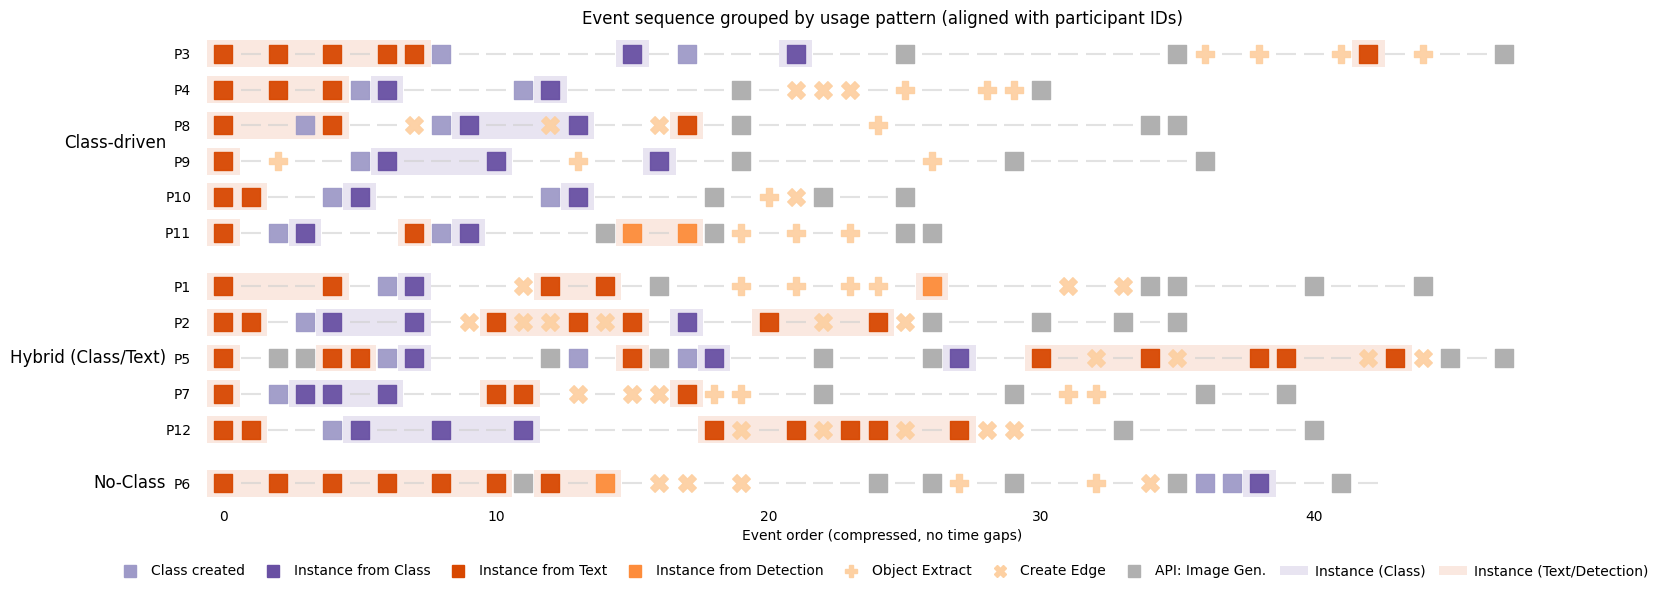

In [511]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

show_events = [
    "instance.created_from_class",
    "instance.created_from_text",
    "instance.created_from_detection",
    "object_node.extract.confirmed",
    "relationship_node.created",
    "class.created",
    "api.generate_image.succeeded",
]

# 팔레트 준비
purple = sns.color_palette("Purples", 3)
orange = sns.color_palette("Oranges", 3)
green  = sns.color_palette("Greens", 3)

event_to_color_custom = {
    "instance.created_from_class": purple[2],   # 진보라
    "class.created":               purple[1],   # 연보라
    "instance.created_from_text":  orange[2],   # 진주황
    "instance.created_from_detection": orange[1], # 연주황
    "object_node.extract.confirmed": orange[0],  # 진초록
    "relationship_node.created":    orange[0],  # 아주 연한 주황
    "api.generate_image.succeeded": "#B0B0B0",  # 노랑 (고정)
}
marker_map_custom = {
    "instance.created_from_class": "s",   # ●
    "class.created": "s",                 # ● (같은 family, 색만 다름)
    "instance.created_from_text": "s",
    "instance.created_from_detection": "s",
    "object_node.extract.confirmed": "P", # ＋ 플러스
    "relationship_node.created": "X",     # × 크로스
    "api.generate_image.succeeded": "s"  # ★
}


# ---- 1) 그룹 매핑 ----
group_map = {
    3: "Class-driven",
    4: "Class-driven",
    8: "Class-driven",
    9: "Class-driven",
    10: "Class-driven",
    11: "Class-driven",
    1: "Hybrid (Class/Text)",
    2: "Hybrid (Class/Text)",
    7: "Hybrid (Class/Text)",
    12: "Hybrid (Class/Text)",
    5: "Hybrid (Class/Text)",
    6: "No-Class",
}
df_sorted["group_label"] = df_sorted["id_group"].map(group_map)

# ---- 참가자 순서 (그룹 포함) ----
group_order = ["Class-driven", "Hybrid (Class/Text)", "No-Class"]
# group_order.reverse()

yticks = []
yticklabels = []
y_val = 0
group_centers = {}

for g in group_order:
    members = sorted([pid for pid, grp in group_map.items() if grp == g])
    for pid in members:
        yticks.append(y_val)
        yticklabels.append(f"P{pid}")  # 참가자만
        y_val += 1
    group_centers[g] = (yticks[-len(members)] + yticks[-1]) / 2  # 그룹 중앙
    y_val += 0.5  # 그룹 간격 띄우기

# ---- 이벤트 좌표 ----
id_to_y = {int(label[1:]): yticks[i] for i, label in enumerate(yticklabels)}
df_sorted["y_axis"] = df_sorted["id_group"].map(id_to_y)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(17, 6))  # ← plt.figure 대신 이렇게 쓰면 ax 확보

event_types = sorted(df_sorted["event"].unique())

# for ev in event_types:
#     mask = df_sorted["event"] == ev
#     marker = marker_map.get(ev, "s")
#     alpha = alpha_map.get(ev, 0.9)

#     ax.scatter(
#         df_sorted.loc[mask, "seq_idx"],
#         df_sorted.loc[mask, "y_axis"],
#         color=event_to_color[ev],
#         marker=marker,
#         s=160,
#         alpha=alpha,
#         label=None,  # ← 자동 범례 OFF
#     )

bg_mask = ~df_sorted["event"].isin(show_events)
ax.scatter(
    df_sorted.loc[bg_mask, "seq_idx"],
    df_sorted.loc[bg_mask, "y_axis"],
    color="#cfcfcf",
    marker="_",  # 가로선
    s=200,  # 길이(크기) 조절
    alpha=0.6,
    zorder=1,
)

# 2) 하이라이트: show_events만 루프에서 컬러/마커로
for ev in show_events:
    mask = df_sorted["event"].eq(ev)
    if not mask.any():
        continue
    marker = marker_map_custom.get(ev, "o")  # 하이라이트는 원형 등으로
    alpha = alpha_map.get(ev, 0.95)
    color = event_to_color_custom.get(ev, "#1f77b4")
    ax.scatter(
        df_sorted.loc[mask, "seq_idx"],
        df_sorted.loc[mask, "y_axis"],
        color=color,
        marker=marker,
        s=160,
        alpha=alpha,
        # edgecolors="black",
        # linewidths=0.4,
        zorder=2,
        label=None,
    )

# # 1) updated.* 두 이벤트는 기본 사각형 바탕부터 깔기
# upd_mask = df_sorted['event'].isin(['instance.updated.text', 'instance.updated.graph'])
# base_color = event_to_color.get('instance.updated.text', event_to_color.get('instance.created_from_text'))
# ax.scatter(
#     df_sorted.loc[upd_mask, 'seq_idx'],
#     df_sorted.loc[upd_mask, 'y_axis'],
#     marker='s', s=160, alpha=1,
#     facecolors=base_color, linewidths=0.6,
#     zorder=2
# )

# # 2) text: 작은 'T'를 우하단에 배치 (offset: +x, -y)
# m_text = df_sorted['event'].eq('instance.updated.text')

# from matplotlib import font_manager as fm
# import matplotlib.patheffects as pe

# # 사용할 폰트 선택 (Times New Roman 없으면 Times → STIXGeneral로 폴백)
# t_font = 'Times New Roman'
# try:
#     fm.findfont(t_font, fallback_to_default=False)
# except:
#     t_font = 'Times'
#     try:
#         fm.findfont(t_font, fallback_to_default=False)
#     except:
#         t_font = 'STIXGeneral'

# # 우하단 'T' 오버레이
# for x, y in df_sorted.loc[m_text, ['seq_idx', 'y_axis']].to_numpy():
#     txt = ax.annotate(
#         'T', (x, y),
#         textcoords='offset points', xytext=(-1, 1),  # 우하단
#         ha='left', va='top',
#         fontsize=10, fontweight='bold', color='black',
#         fontname=t_font,          # ← 여기!
#         zorder=5
#     )

# 참가자 라벨
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

# 그룹 라벨 (왼쪽에 크게) - (참고: x=-3는 xlim(left=-1)면 잘릴 수 있음)
for g, center in group_centers.items():
    ax.text(-2.1, center, g, va="center", ha="right", fontsize=12)

ax.set_xlabel("Event order (compressed, no time gaps)")
ax.set_title("Event sequence grouped by usage pattern (aligned with participant IDs)")
ax.set_xlim(left=-1)

# 원하는 그룹 순서 지정
group_order = ["class", "instance", "object", "edge", "layout", "api"]

# # (옵션) 그룹 내 이벤트 순서 지정
# event_order = {
#     "instance": [
#         "instance.created_from_class",
#         "instance.created_from_text",
#         "instance.created_from_detection",
#         "instance.updated",
#     ],
#     "class": ["class.created", "class.updated", "class.instances_reset"],
#     "layout": ["layout.start", "layout.moved", "layout.resized", "layout.end"],
# }

# make_group_event_legend(
#     ax,
#     event_types=event_types,
#     event_to_group=event_to_group,
#     event_to_color=event_to_color,
#     marker_map=marker_map,
#     group_display=group_display,
#     event_display=event_display,
#     title="Event Groups + Events",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1),
#     group_order=group_order,  # ✅ 여기!
#     events_to_show=show_events,
# )
# 색상 (네 팔레트 기반)
PURPLE = tuple(purple[2])   # Class 기반
ORANGE = tuple(orange[2])   # Text 기반

SET_CLASS = {"instance.created_from_class"}
SET_TEXT  = {"instance.created_from_text", "instance.created_from_detection"}

for pid in df_sorted["id_group"].unique():
    y   = id_to_y[pid]
    row = df_sorted[df_sorted["id_group"] == pid]

    # 보라 밴드: class 기반 instance 생성
    draw_band_runs(ax, row, SET_CLASS, y, PURPLE,
                   pad=0.6, alpha=0.15, max_gap=4, z=0.05)

    # 주황 밴드: text/detection 기반 instance 생성
    draw_band_runs(ax, row, SET_TEXT,  y, ORANGE,
                   pad=0.6, alpha=0.12, max_gap=4, z=0.06)


from matplotlib.lines import Line2D

# 실제 그려진 이벤트만 가져오기
present_events = [ev for ev in show_events if df_sorted["event"].eq(ev).any()]

# 보기 좋은 순서로 정렬
legend_order = [
    "class.created",
    "instance.created_from_class",
    "instance.created_from_text",
    "instance.created_from_detection",
    "object_node.extract.confirmed",
    "relationship_node.created",
    "api.generate_image.succeeded",
]
present_events = [ev for ev in legend_order if ev in present_events]

# 표시용 이름
display_name = {
    "class.created": "Class created",
    "instance.created_from_class": "Instance from Class",
    "instance.created_from_text": "Instance from Text",
    "instance.created_from_detection": "Instance from Detection",
    "object_node.extract.confirmed": "Object Extract",
    "relationship_node.created": "Relationship",
    "api.generate_image.succeeded": "API: Image Generated",
}

# 범례 핸들 만들기
handles, labels = [], []
for ev in present_events:
    color  = event_to_color_custom.get(ev, "#333333")
    marker = marker_map_custom.get(ev, "o")
    h = Line2D(
        [0], [0],
        marker=marker,
        linestyle="None",
        markersize=10,
        markerfacecolor=color,
        markeredgecolor=color,
        alpha=0.9,
    )
    handles.append(h)
    labels.append(display_name.get(ev, ev))
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- 1) 이벤트 범례 핸들(이미 쓰던 handles/labels 만드는 부분) ---
event_order = [
    "class.created",
    "instance.created_from_class",
    "instance.created_from_text",
    "instance.created_from_detection",
    "object_node.extract.confirmed",
    "relationship_node.created",
    "api.generate_image.succeeded",
]
present = [ev for ev in event_order if df_sorted["event"].eq(ev).any()]

event_handles, event_labels = [], []
for ev in present:
    color  = event_to_color_custom.get(ev, "#666")
    marker = marker_map_custom.get(ev, "o")
    event_handles.append(Line2D([0],[0], marker=marker, linestyle="None",
                                markersize=9, markerfacecolor=color, markeredgecolor=color))
    # 짧고 통일된 이름
    name = {
        "class.created": "Class created",
        "instance.created_from_class": "Instance from Class",
        "instance.created_from_text": "Instance from Text",
        "instance.created_from_detection": "Instance from Detection",
        "object_node.extract.confirmed": "Object Extract",
        "relationship_node.created": "Create Edge",
        "api.generate_image.succeeded": "API: Image Gen.",
    }.get(ev, ev)
    event_labels.append(name)

# --- 2) 밴드(보라/주황) 설명 핸들 ---
# PURPLE/ORANGE는 네가 밴드에 쓴 색(튜플 RGB) 사용
band_handles = [
    Patch(facecolor=(PURPLE[0], PURPLE[1], PURPLE[2], 0.15), edgecolor="none", label="Band: Class-instance"),
    Patch(facecolor=(ORANGE[0], ORANGE[1], ORANGE[2], 0.12), edgecolor="none", label="Band: Text-instance"),
]
band_labels  = ["Instance (Class)", "Instance (Text/Detection)"]

# --- 3) 아래 가로 범례로 합치기 ---
handles = event_handles + band_handles
labels  = event_labels + band_labels

ncols = len(labels)
leg = ax.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),  # 플롯 아래
    ncol=ncols,                   # 가로로 쭉
    frameon=False,
    handletextpad=0.5,
    columnspacing=1.0,
)
plt.subplots_adjust(bottom=0.16)  # 잘리지 않게 아래 여백


# 아래 여백 확보 (범례가 잘리지 않도록)
# plt.subplots_adjust(bottom=0.1)      # 필요 시 값 조절
# 저장할 때
# plt.savefig(path, bbox_inches="tight", pad_inches=0.05)


plt.gca().invert_yaxis()
# 축 테두리(4면) 제거
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0)
# ax.axvline(-0.8, color="grey", linestyle="-", lw=1, alpha=0.8)
plt.tight_layout()
plt.savefig("figure_0903/log_study1.pdf")
plt.show()

In [471]:
import numpy as np
import pandas as pd

# (1) object_node.extract.confirmed 카운트
obj_counts = (
    df_all[df_all["event"] == "object_node.extract.confirmed"]
    .groupby("id_group")
    .size()
    .reindex(sorted(df_all["id_group"].unique()), fill_value=0)
    .rename("obj_cnt")
)

# (2) 기존 상위 그룹 레이블(네가 쓰던 것) 예시
group_map = {
    3: "Class-driven",
    4: "Class-driven",
    8: "Class-driven",
    9: "Class-driven",
    10: "Class-driven",
    11: "Class-driven",
    1: "Hybrid",
    2: "Hybrid",
    7: "Hybrid",
    12: "Hybrid",
    5: "Progressive",
    6: "No-Class",
}
group_ser = pd.Series(group_map, name="group")

# (3) 분위수 기준으로 Heavy/Light/None 부여 (그룹별 독립 기준)
df_g = pd.concat([obj_counts, group_ser], axis=1)
sub_labels = {}
for g, sub in df_g.groupby("group"):
    # None
    none_ids = sub.index[sub["obj_cnt"] == 0]
    for pid in none_ids:
        sub_labels[pid] = f"{g}-Object-None"
    # Heavy/Light (0이 아닌 대상만 분위수로 분리)
    pos = sub[sub["obj_cnt"] > 0]["obj_cnt"]
    if len(pos) > 0:
        thr = np.quantile(pos, 0.67) if len(pos) >= 3 else pos.median()
        for pid, cnt in pos.items():
            sub_labels[pid] = f"{g}-Object-Heavy" if cnt >= thr else f"{g}-Object-Light"

subtype_ser = pd.Series(sub_labels, name="subtype")  # id_group -> subtype
# 필요하면 테이블로 확인
summary = df_g.join(subtype_ser)
print(summary.sort_index())

    obj_cnt         group                    subtype
1         4        Hybrid        Hybrid-Object-Heavy
2         0        Hybrid         Hybrid-Object-None
3         4  Class-driven  Class-driven-Object-Heavy
4         3  Class-driven  Class-driven-Object-Heavy
5         0   Progressive    Progressive-Object-None
6         2      No-Class      No-Class-Object-Heavy
7         4        Hybrid        Hybrid-Object-Heavy
8         1  Class-driven  Class-driven-Object-Light
9         3  Class-driven  Class-driven-Object-Heavy
10        1  Class-driven  Class-driven-Object-Light
11        3  Class-driven  Class-driven-Object-Heavy
12        0        Hybrid         Hybrid-Object-None


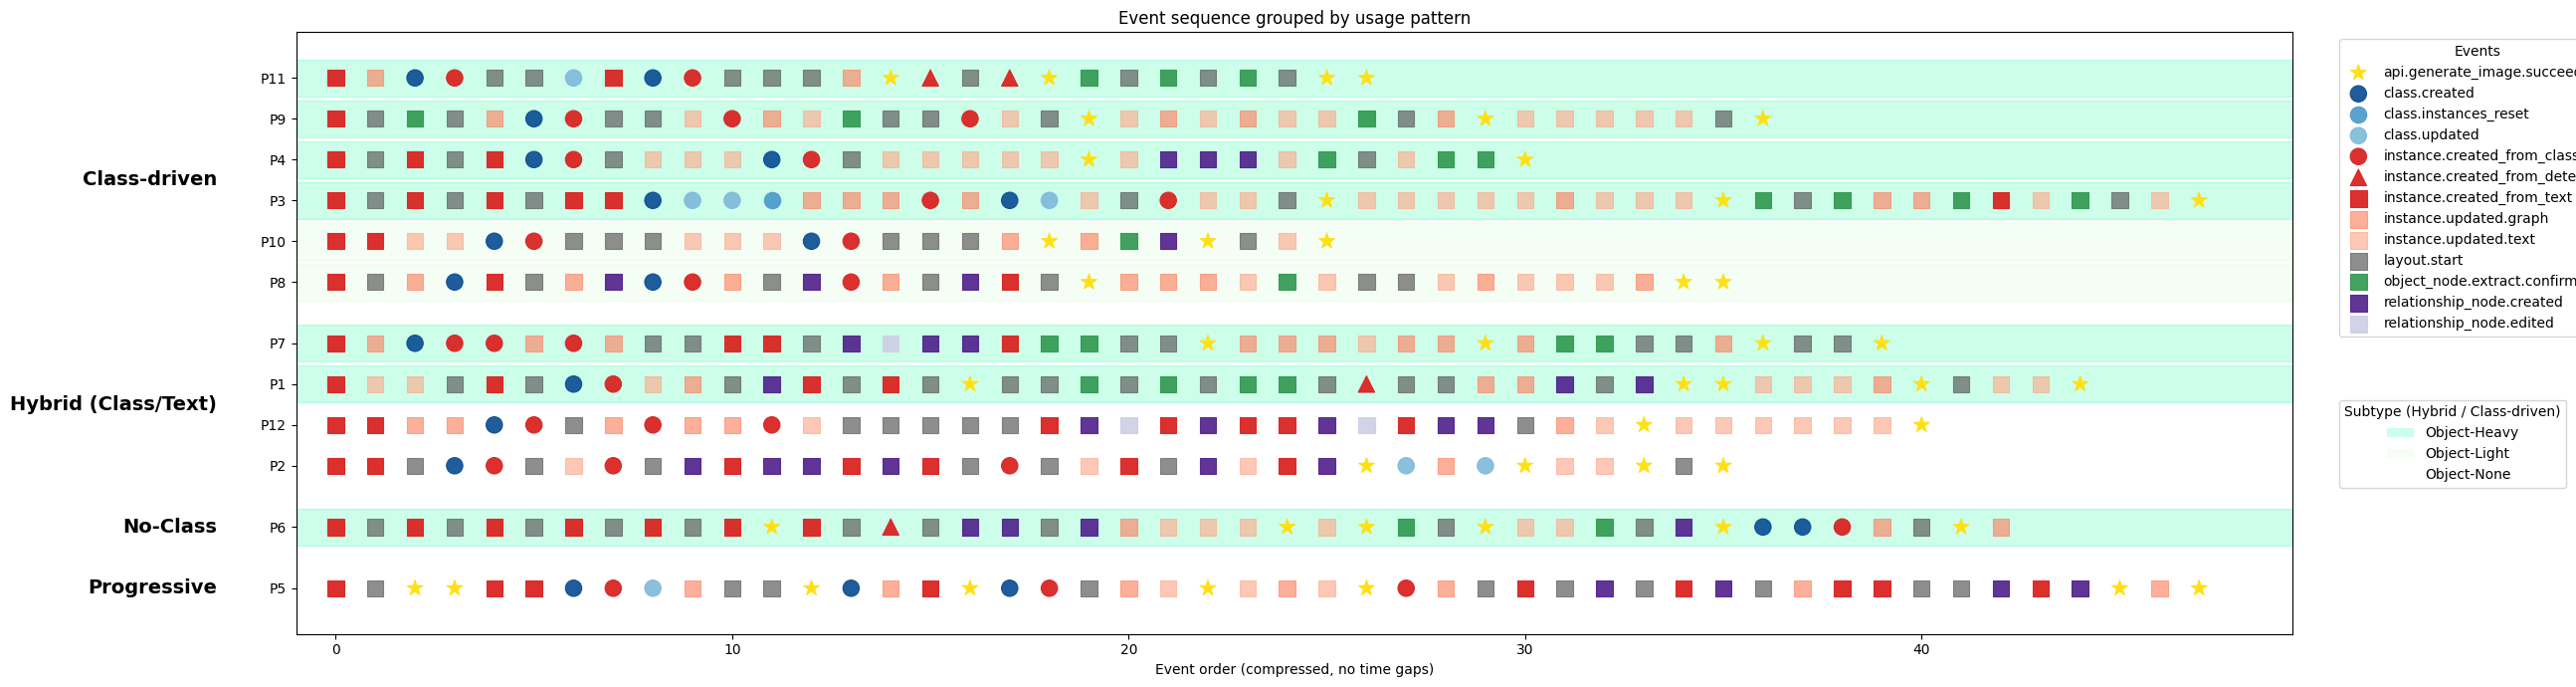

In [406]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ────────────────────────────────────────────────────────────────────────────
# 0) 준비: 시간 정렬 + 순서 인덱스(간격 제거)
# ────────────────────────────────────────────────────────────────────────────
df = df_all.copy()

if "timestamp" in df.columns:
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["id_group", "timestamp"]).copy()
else:
    # timestamp가 없으면 원래 순서대로 id_group 내에서 정렬
    df = df.sort_values(["id_group"]).copy()

df["seq_idx"] = df.groupby("id_group").cumcount()

# ────────────────────────────────────────────────────────────────────────────
# 1) 상위 그룹(전략) 매핑  ← 네가 쓰던 것 그대로
# ────────────────────────────────────────────────────────────────────────────
group_map = {
    3: "Class-driven",
    4: "Class-driven",
    8: "Class-driven",
    9: "Class-driven",
    10: "Class-driven",
    11: "Class-driven",
    1: "Hybrid (Class/Text)",
    2: "Hybrid (Class/Text)",
    7: "Hybrid (Class/Text)",
    12: "Hybrid (Class/Text)",
    5: "Progressive",
    6: "No-Class",
}
df["group"] = df["id_group"].map(group_map)

# ────────────────────────────────────────────────────────────────────────────
# 2) object 사용량으로 Hybrid/Class-driven을 서브타입 분기 (Heavy / Light / None)
#    - 같은 상위그룹 내에서 분위수 기준으로 나눔
# ────────────────────────────────────────────────────────────────────────────
obj_cnt = df[df["event"] == "object_node.extract.confirmed"].groupby("id_group").size()
obj_cnt = obj_cnt.reindex(sorted(df["id_group"].unique()), fill_value=0)

tmp = pd.DataFrame({"group": pd.Series(group_map), "obj_cnt": obj_cnt}).dropna(
    subset=["group"]
)

subtype = {}
for g, sub in tmp.groupby("group"):
    # No-Class는 서브타입 구분 안 함
    if g not in ["Hybrid (Class/Text)", "Class-driven", "No-Class", "Progressive"]:
        for pid in sub.index:
            subtype[pid] = f"{g}"
        continue

    # None
    none_ids = sub.index[sub["obj_cnt"] == 0]
    for pid in none_ids:
        subtype[pid] = f"{g}-Object-None"

    # Heavy/Light (0 초과만)
    pos = sub[sub["obj_cnt"] > 0]["obj_cnt"]
    if len(pos) > 0:
        thr = np.quantile(pos, 0.67) if len(pos) >= 3 else pos.median()
        for pid, cnt in pos.items():
            subtype[pid] = f"{g}-Object-Heavy" if cnt >= thr else f"{g}-Object-Light"

# 맵핑 붙이기
df["subtype"] = df["id_group"].map(subtype).fillna(df["group"])


# 기본값 보정 함수
def style_for(ev):
    marker = marker_map.get(ev, "s")
    alpha = alpha_map.get(ev, 0.9)
    edge = 1  # edge_map.get(ev, 'k' if ev.startswith('instance.created_') else 'none')
    lw = 0.8 if edge != "none" else 0
    return marker, alpha, _, lw


# ────────────────────────────────────────────────────────────────────────────
# 4) y축 구성 (그룹 내부 정렬: Heavy → Light → None, 동률은 obj_cnt 내림차순 → id)
# ────────────────────────────────────────────────────────────────────────────
group_order = [
    "Class-driven",
    "Hybrid (Class/Text)",
    "No-Class",
    "Progressive",
]  # 원하는 순서
group_order.reverse()

# 서브타입 우선순위
prio = {"Object-Heavy": 2, "Object-Light": 1, "Object-None": 0}


def subtype_bucket(pid):
    """서브타입 라벨에서 버킷만 추출 (No-Class는 None 취급)"""
    st = subtype.get(pid, group_map.get(pid, ""))
    if "Object-Heavy" in st:
        return "Object-Heavy"
    if "Object-Light" in st:
        return "Object-Light"
    if "Object-None" in st:
        return "Object-None"
    return "Object-None"  # No-Class 포함


def sort_key(pid):
    bucket = subtype_bucket(pid)
    return (prio.get(bucket, 3), -int(obj_cnt.get(pid, 0)), int(pid))


rows = []
y = 0
group_centers = {}
yticks, ylabels = [], []

for g in group_order:
    # 이 그룹의 멤버 수집
    members = [pid for pid, gg in group_map.items() if gg == g]
    if not members:
        continue

    # 버킷 우선 정렬
    members_sorted = sorted(members, key=sort_key)

    start_y = y
    for pid in members_sorted:
        rows.append((pid, y))
        yticks.append(y)
        short = subtype.get(pid, g).replace("Class-driven-", "").replace("Hybrid-", "")
        ylabels.append(f"P{pid}")
        y += 1
    group_centers[g] = (start_y + y - 1) / 2
    y += 0.5  # 그룹 간 빈 줄

# id→y 매핑 업데이트 및 y축 값 부여
id_to_y = dict(rows)
df["y_axis"] = df["id_group"].map(id_to_y)

# ────────────────────────────────────────────────────────────────────────────
# 5) 플롯
# ────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 7))

# (a) 서브타입 하이라이트 밴드 (Hybrid/Class-driven만)
for pid, yy in id_to_y.items():
    st = subtype.get(pid, group_map.get(pid, ""))
    if "Object-Heavy" in st:
        ax.axhspan(yy - 0.45, yy + 0.45, color="mediumspringgreen", alpha=0.2, zorder=0)
    elif "Object-Light" in st:
        ax.axhspan(yy - 0.45, yy + 0.45, color="palegreen", alpha=0.1, zorder=0)
    elif "Object-None" in st:
        ax.axhspan(yy - 0.45, yy + 0.45, color="gainsboro", alpha=0.0, zorder=0)

# (b) 이벤트 점
for ev in event_types:
    m = df["event"] == ev
    marker, aa, edge, lw = style_for(ev)
    ax.scatter(
        df.loc[m, "seq_idx"],
        df.loc[m, "y_axis"],
        c=[event_to_color[ev]] * m.sum(),
        marker=marker,
        s=140,
        alpha=aa,
        linewidths=lw,
        label=ev if ev not in ax.get_legend_handles_labels()[1] else None,
    )

# (c) y축: 참가자
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

# (d) 왼쪽에 상위 그룹 라벨
for g, cy in group_centers.items():
    ax.text(-3, cy, g, ha="right", va="center", fontsize=14, fontweight="bold")

ax.set_xlabel("Event order (compressed, no time gaps)")
# ax.set_ylabel("Participants (subtype in brackets)")
ax.set_title("Event sequence grouped by usage pattern")

# (e) 범례: 이벤트 + 서브타입
event_legend = ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Events")
ax.add_artist(event_legend)

sub_legend = [
    Patch(
        facecolor="mediumspringgreen", alpha=0.2, edgecolor="none", label="Object-Heavy"
    ),
    Patch(facecolor="palegreen", alpha=0.1, edgecolor="none", label="Object-Light"),
    Patch(facecolor="gainsboro", alpha=0, edgecolor="none", label="Object-None"),
]
ax.legend(
    handles=sub_legend,
    title="Subtype (Hybrid / Class-driven)",
    bbox_to_anchor=(1.02, 0.40),
    loc="upper left",
)
plt.xlim(left=-1)

plt.tight_layout()
plt.show()

In [407]:
# 관심 이벤트 목록
target_events = [
    "instance.created_from_class",
    "instance.created_from_text",
    "instance.created_from_detection",
]

# id_group별 이벤트 개수 집계 (pivot)
counts = (
    df[df["event"].isin(target_events)]
    .groupby(["id_group", "event"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=target_events, fill_value=0)  # 순서 고정
)

# 총합 및 비율 계산
counts["total"] = counts.sum(axis=1)
counts["class_ratio"] = counts["instance.created_from_class"] / counts["total"].replace(
    0, np.nan
)

# 보기 좋게 reset_index
result = counts.reset_index()

result.sort_values(by=["class_ratio"], inplace=True, ascending=False)
result

event,id_group,instance.created_from_class,instance.created_from_text,instance.created_from_detection,total,class_ratio
8,9,3,1,0,4,0.750000
9,10,2,2,0,4,0.500000
6,7,3,4,0,7,0.428571
3,4,2,3,0,5,0.400000
7,8,2,3,0,5,0.400000
10,11,2,2,2,6,0.333333
1,2,3,7,0,10,0.300000
11,12,3,7,0,10,0.300000
2,3,2,6,0,8,0.250000
4,5,3,9,0,12,0.250000


In [408]:
result.sort_values(
    by=["instance.created_from_class", "class_ratio"], inplace=True, ascending=False
)
result

event,id_group,instance.created_from_class,instance.created_from_text,instance.created_from_detection,total,class_ratio
8,9,3,1,0,4,0.750000
6,7,3,4,0,7,0.428571
1,2,3,7,0,10,0.300000
11,12,3,7,0,10,0.300000
4,5,3,9,0,12,0.250000
9,10,2,2,0,4,0.500000
3,4,2,3,0,5,0.400000
7,8,2,3,0,5,0.400000
10,11,2,2,2,6,0.333333
2,3,2,6,0,8,0.250000
